# Assignment 3 - Convection of a Scalar

Solve the following problems and explain your results.

In [1]:
from Classes.Grid import Grid
from Classes.ScalarCoeffs import ScalarCoeffs
from Classes.BoundaryConditions import BoundaryLocation, DirichletBc, NeumannBc, RobinBc
from Classes.Models import DiffusionModel, SurfaceConvectionModel, FirstOrderTransientModel, SecondOrderTransientModel
from Classes.LinearSolver import solve

import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt

import numpy as np

#UDS
class UpwindAdvectionModel:
    """Class defining an upwind advection model"""

    def __init__(self, grid, phi, Uhe, rho, cp, west_bc, east_bc):
        """Constructor"""
        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc
        self._alphae = np.zeros(self._grid.ncv+1)
        self._phie = np.zeros(self._grid.ncv+1)

    def add(self, coeffs):
        """Function to add diffusion terms to coefficient arrays"""

        # Calculate the weighting factors
        for i in range(self._grid.ncv+1):
            if self._Uhe[i] >= 0:
                self._alphae[i] = 1
            else:
                self._alphae[i] = -1
        
        # Calculate the east integration point values (including both boundaries)
        self._phie = (1 + self._alphae)/2*self._phi[0:-1] + (1 - self._alphae)/2*self._phi[1:]
        
        # Calculate the face mass fluxes
        mdote = self._rho*self._Uhe*self._grid.Af
        
        # Calculate the west and east face advection flux terms for each face
        flux_w = self._cp*mdote[:-1]*self._phie[:-1]
        flux_e = self._cp*mdote[1:]*self._phie[1:]
        
        # Calculate mass imbalance term
        imbalance = - self._cp*mdote[1:]*self._phi[1:-1] + self._cp*mdote[:-1]*self._phi[1:-1]
          
        # Calculate the linearization coefficients
        coeffW = - self._cp*mdote[:-1]*(1 + self._alphae[:-1])/2
        coeffE = self._cp*mdote[1:]*(1 - self._alphae[1:])/2
        coeffP = - coeffW - coeffE

        # Modify the linearization coefficients on the boundaries
        coeffP[0] += coeffW[0]*self._west_bc.coeff()
        coeffP[-1] += coeffE[-1]*self._east_bc.coeff()

        # Zero the boundary coefficients that are not used
        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Calculate the net flux from each cell
        flux = flux_e - flux_w

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux)
        coeffs.accumulate_rP(imbalance)

        # Return the modified coefficient array
        return coeffs
        
class CDSAdvectionModel:
    """Class defining an upwind advection model with deffered CDS"""

    def __init__(self, grid, phi, Uhe, rho, cp, west_bc, east_bc):
        """Constructor"""
        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc
        self._alphae = np.zeros(self._grid.ncv+1)
        self._phie_uds = np.zeros(self._grid.ncv + 1)
        self._phie_cds = np.zeros(self._grid.ncv + 1)

    def add(self, coeffs):
        """Function to add diffusion terms to coefficient arrays"""

        # Calculate the weighting factors
        for i in range(self._grid.ncv+1):
            if self._Uhe[i] >= 0:
                self._alphae[i] = 1
            else:
                self._alphae[i] = -1
        
        # Calculate the east integration point values (including both boundaries)
        self._phie_uds = (1 + self._alphae)/2*self._phi[0:-1] + (1 - self._alphae)/2*self._phi[1:]
        self._phie_cds = 0.5 * (self._phi[0:-1] + self._phi[1:])
        
        # Calculate the face mass fluxes
        mdote = self._rho*self._Uhe*self._grid.Af
        
        # Calculate the west and east face advection flux terms for each face (UDS)
        flux_w_uds = self._cp * mdote[:-1] * self._phie_uds[:-1]
        flux_e_uds = self._cp * mdote[1:]  * self._phie_uds[1:]

        flux_uds = flux_e_uds - flux_w_uds
        
        #CDS fluxes 
        flux_w_cds = self._cp * mdote[:-1] * self._phie_cds[:-1]
        flux_e_cds = self._cp * mdote[1:]  * self._phie_cds[1:]

        flux_cds = flux_e_cds - flux_w_cds

        
        
        # Calculate mass imbalance term
        imbalance = - self._cp*mdote[1:]*self._phi[1:-1] + self._cp*mdote[:-1]*self._phi[1:-1]
          
        # Calculate the linearization coefficients
        coeffW = - self._cp*mdote[:-1]*(1 + self._alphae[:-1])/2
        coeffE = self._cp*mdote[1:]*(1 - self._alphae[1:])/2
        coeffP = - coeffW - coeffE

        # Modify the linearization coefficients on the boundaries
        coeffP[0] += coeffW[0]*self._west_bc.coeff()
        coeffP[-1] += coeffE[-1]*self._east_bc.coeff()

        # Zero the boundary coefficients that are not used
        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Calculate the net flux from each cell
        flux = flux_uds + (flux_cds - flux_uds)

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux)
        coeffs.accumulate_rP(imbalance)

        # Return the modified coefficient array
        return coeffs
        
class QUICKAdvectionModel:
    """Class defining a deferred-correction QUICK advection model"""

    def __init__(self, grid, phi, Uhe, rho, cp, west_bc, east_bc):
        """Constructor"""
        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc

        self._alphae = np.zeros(self._grid.ncv + 1)
        self._phie_uds = np.zeros(self._grid.ncv + 1)
        self._phie_quick = np.zeros(self._grid.ncv + 1)

    def add(self, coeffs):
        """Function to add deferred-correction QUICK advection terms"""
        
        #UDS weighting factors
        for i in range(self._grid.ncv + 1):
            if self._Uhe[i] >= 0.0:
                self._alphae[i] = 1.0
            else:
                self._alphae[i] = -1.0

        # Boundary faces:
        self._alphae[0] = 0.0
        self._alphae[-1] = 0.0
        
        # UDS face values
        self._phie_uds = (
            (1.0 + self._alphae) / 2.0 * self._phi[0:-1]
            + (1.0 - self._alphae) / 2.0 * self._phi[1:]
        )

        # QUICK face values
        self._phie_quick[:] = self._phie_uds[:]

        for i in range(1, self._grid.ncv):
            if self._Uhe[i] >= 0.0:
                self._phie_quick[i] = (
                    - self._phi[i - 1]
                    + 6.0 * self._phi[i]
                    + 3.0 * self._phi[i + 1]
                ) / 8.0
            else:
                self._phie_quick[i] = (
                    3.0 * self._phi[i]
                    + 6.0 * self._phi[i + 1]
                    - self._phi[i + 2]
                ) / 8.0


        #Face mass fluxes
        mdote = self._rho * self._Uhe * self._grid.Af

        #UDS fluxes
        flux_w_uds = self._cp * mdote[:-1] * self._phie_uds[:-1]
        flux_e_uds = self._cp * mdote[1:]  * self._phie_uds[1:]

        flux_uds = flux_e_uds - flux_w_uds

        # QUICK fluxes
        flux_w_quick = self._cp * mdote[:-1] * self._phie_quick[:-1]
        flux_e_quick = self._cp * mdote[1:]  * self._phie_quick[1:]

        flux_quick = flux_e_quick - flux_w_quick

        # F = F_UDS + (F_QUICK - F_UDS)
        flux = flux_uds + (flux_quick - flux_uds)

        #Mass imbalance term
        imbalance = (
            - self._cp * mdote[1:]  * self._phi[1:-1]
            + self._cp * mdote[:-1] * self._phi[1:-1]
        )

        #Linearization coefficients from UDS only
        coeffW = - self._cp * mdote[:-1] * (1.0 + self._alphae[:-1]) / 2.0
        coeffE =   self._cp * mdote[1:]  * (1.0 - self._alphae[1:])  / 2.0
        coeffP = - coeffW - coeffE

        # Boundary coefficient treatment
        coeffP[0] += coeffW[0] * self._west_bc.coeff()
        coeffP[-1] += coeffE[-1] * self._east_bc.coeff()

        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)

        coeffs.accumulate_rP(flux)
        coeffs.accumulate_rP(imbalance)

        return coeffs

## Problem 1

Consider a convection/diffusion problem that has Dirichlet conditions on temperature imposed on both ends (see the figure below). This is an unusual problem that would be difficult to reproduce in a laboratory, but it is an interesting problem by which to observe the performance of advection schemes.

![Problem1](Figures/3-Problem1.png)
   
The exact solution to this problem is given by:

$$
    T(x)= T_1 + \frac{e^{x Pe/L} - 1}{e^{Pe} - 1}(T_2 - T_1)
$$

where $Pe$ is defined as $Pe= u L/\alpha$.  Solve this problem numerically for $Pe = 50$ by imposing:

- $L$ = 1 [m]
- $\rho$ = 1 [kg/m$^3$]
- $c_p$ = 1 [J/kg$\cdot$K]
- $u$ = 1 [m/s]
- $k$ = 0.02 [[W/m$\cdot$K]]
- $T_1$ = 0 [$^\circ$C]
- $T_2$ = 1 [$^\circ$C]

Discretize the one-dimensional domain using 10 equal sized control-volumes.  Initialize the field variables as $T$ = 0.0 [K] and $u$ = 1 [m/s]. Then, carry out the following:

1. Solve the problem using UDS, CDS, and QUICK (use $\Delta t = 10^{10}$ [s]).  Modify the value of $\alpha_e$ on the domain boundaries such that the value of temperature on the face is equal to the specified boundary temperature.
2. Plot the results for $T$ for all cases along with the exact solution. Discuss your results.
4. Re-run the case using 20, 40 and 80 uniformly spaced control volumes.  Discuss your results.

In [2]:
#define funciton for analytical solution
def analytical_T(x, L):
    return T1 + (np.exp(x*Pe/L) - 1)/(np.exp(Pe) - 1) * (T2 - T1) 

In [3]:
def run_convection_diffusion_case(ncv, advection_class):
    # Define the grid
    lx = 1.0
    ly = 0.1
    lz = 0.1
    grid = Grid(lx, ly, lz, ncv)

    # Time information
    nTime = 1
    dt = 1e10
    time = 0.0

    # Iteration settings
    maxIter = 100
    converged = 1e-8

    # Thermophysical properties
    rho = 1.0
    cp = 1.0
    k = 0.02

    # Initial conditions
    T0 = 300.0
    U0 = 1.0

    # Initialize field arrays
    T = T0 * np.ones(grid.ncv + 2)
    Uhe = U0 * np.ones(grid.ncv + 1)

    # Boundary conditions
    west_bc = DirichletBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = DirichletBc(T, grid, 1.0, BoundaryLocation.EAST)

    west_bc.apply()
    east_bc.apply()

    # Old field
    Told = np.copy(T)

    # Models
    transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dt)
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    advection = advection_class(grid, T, Uhe, rho, cp, west_bc, east_bc)

    # Coefficients
    coeffs = ScalarCoeffs(grid.ncv)

    # Time loop
    for tStep in range(nTime):
        time += dt
        print(f"\nncv = {ncv}, Scheme = {advection_class.__name__}")
        print(f"Timestep = {tStep}; Time = {time}")

        Told[:] = T[:]

        # Iteration loop
        for i in range(maxIter):
            coeffs.zero()

            coeffs = diffusion.add(coeffs)
            coeffs = advection.add(coeffs)
            coeffs = transient.add(coeffs)

            maxResid = norm(coeffs.rP, np.inf)
            avgResid = np.mean(np.abs(coeffs.rP))

            print(
                "Iteration = {}; Max. Resid. = {:.4e}; Avg. Resid. = {:.4e}".format(
                    i, maxResid, avgResid
                )
            )

            if maxResid < converged:
                break

            dT = solve(coeffs)

            T[1:-1] += dT

            west_bc.apply()
            east_bc.apply()

    return grid, np.copy(T)


In [4]:
# Run 3 advection schemes with the same mesh: ncv = 20

ncv = 20

schemes = {
    "UDS": UpwindAdvectionModel,
    "CDS": CDSAdvectionModel,
    "QUICK": QUICKAdvectionModel,
}

results_20 = {}

for scheme_name, scheme_class in schemes.items():
    grid, T_sol = run_convection_diffusion_case(
        ncv=ncv,
        advection_class=scheme_class
    )

    results_20[scheme_name] = {
        "grid": grid,
        "T": T_sol,
    }


ncv = 20, Scheme = UpwindAdvectionModel
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 5.4000e+00; Avg. Resid. = 3.8960e-01
Iteration = 1; Max. Resid. = 2.4923e-15; Avg. Resid. = 5.8643e-16

ncv = 20, Scheme = CDSAdvectionModel
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 3.9000e+00; Avg. Resid. = 2.3985e-01
Iteration = 1; Max. Resid. = 1.0833e+00; Avg. Resid. = 9.6718e-02
Iteration = 2; Max. Resid. = 4.1763e-01; Avg. Resid. = 3.9860e-02
Iteration = 3; Max. Resid. = 2.1710e-01; Avg. Resid. = 1.8469e-02
Iteration = 4; Max. Resid. = 1.0194e-01; Avg. Resid. = 9.4893e-03
Iteration = 5; Max. Resid. = 4.4721e-02; Avg. Resid. = 4.7709e-03
Iteration = 6; Max. Resid. = 2.0742e-02; Avg. Resid. = 2.6704e-03
Iteration = 7; Max. Resid. = 1.1344e-02; Avg. Resid. = 1.4357e-03
Iteration = 8; Max. Resid. = 5.7161e-03; Avg. Resid. = 7.7872e-04
Iteration = 9; Max. Resid. = 2.9619e-03; Avg. Resid. = 4.3919e-04
Iteration = 10; Max. Resid. = 1.6749e-03; Avg. Resid. = 2.3

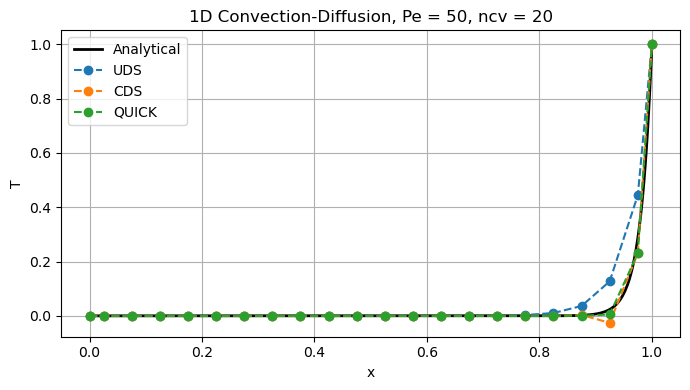

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
T1 = 0
T2 = 1
Pe = 50
x_an = np.linspace(0.0, 1, 500)
T_an = analytical_T(x_an, 1)

plt.figure(figsize=(7, 4))

plt.plot(x_an, T_an, "k-", linewidth=2, label="Analytical")

for scheme_name in schemes.keys():
    grid = results_20[scheme_name]["grid"]
    T_sol = results_20[scheme_name]["T"]


    plt.plot(
        grid.xP,
        T_sol,
        marker="o",
        linestyle="--",
        label=scheme_name
    )

plt.xlabel("x")
plt.ylabel("T")
plt.title("1D Convection-Diffusion, Pe = 50, ncv = 20")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Dissucsion for UDS CDS and QUICK for NCV = 20

For ncv=20, the cell Peclet number is Pe =50/20=2.5, indicating that the solution is still convection dominated at the cell level. The analytical solution remains close to zero over most of the domain and rises sharply near the outlet boundary. The UDS scheme gives a bounded and stable solution, but it is overly diffusive and less accurate near the outlet. The CDS scheme gives less numerical diffusion, but it produces an unphysical undershoot near the outlet because Pe>2, which violates the usual boundedness condition for central differencing. The QUICK scheme gives the best qualitative agreement among the three schemes on this mesh, since it reduces numerical diffusion without producing the same level of oscillation as CDS.

In [6]:
L = 1.0
T1 = 0.0
T2 = 1.0
Pe = 50.0

ncv_list = [20, 40, 80]

schemes = {
    "UDS": UpwindAdvectionModel,
    "CDS": CDSAdvectionModel,
    "QUICK": QUICKAdvectionModel,
}

results = {}

for ncv in ncv_list:
    results[ncv] = {}

    for scheme_name, scheme_class in schemes.items():
        grid, T_sol = run_convection_diffusion_case(ncv, scheme_class)
        results[ncv][scheme_name] = {
            "grid": grid,
            "T": T_sol,
        }


ncv = 20, Scheme = UpwindAdvectionModel
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 5.4000e+00; Avg. Resid. = 3.8960e-01
Iteration = 1; Max. Resid. = 2.4923e-15; Avg. Resid. = 5.8643e-16

ncv = 20, Scheme = CDSAdvectionModel
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 3.9000e+00; Avg. Resid. = 2.3985e-01
Iteration = 1; Max. Resid. = 1.0833e+00; Avg. Resid. = 9.6718e-02
Iteration = 2; Max. Resid. = 4.1763e-01; Avg. Resid. = 3.9860e-02
Iteration = 3; Max. Resid. = 2.1710e-01; Avg. Resid. = 1.8469e-02
Iteration = 4; Max. Resid. = 1.0194e-01; Avg. Resid. = 9.4893e-03
Iteration = 5; Max. Resid. = 4.4721e-02; Avg. Resid. = 4.7709e-03
Iteration = 6; Max. Resid. = 2.0742e-02; Avg. Resid. = 2.6704e-03
Iteration = 7; Max. Resid. = 1.1344e-02; Avg. Resid. = 1.4357e-03
Iteration = 8; Max. Resid. = 5.7161e-03; Avg. Resid. = 7.7872e-04
Iteration = 9; Max. Resid. = 2.9619e-03; Avg. Resid. = 4.3919e-04
Iteration = 10; Max. Resid. = 1.6749e-03; Avg. Resid. = 2.3

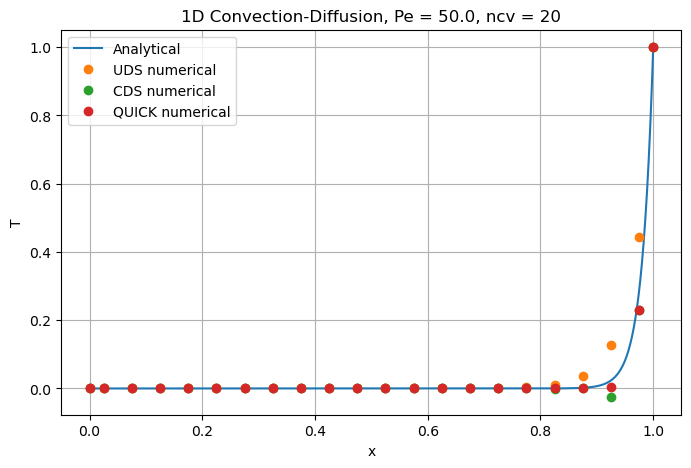

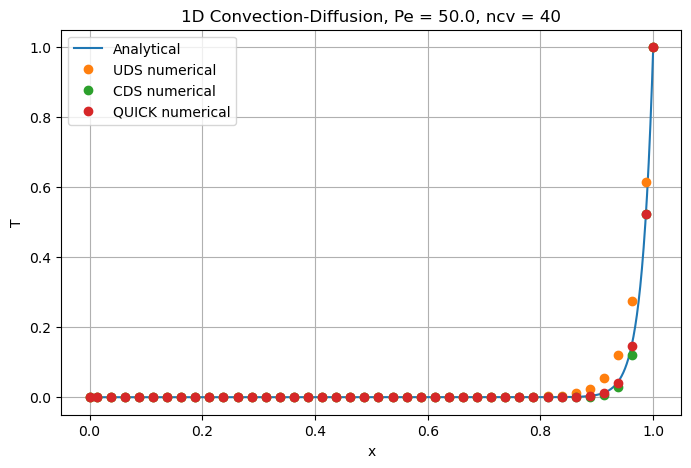

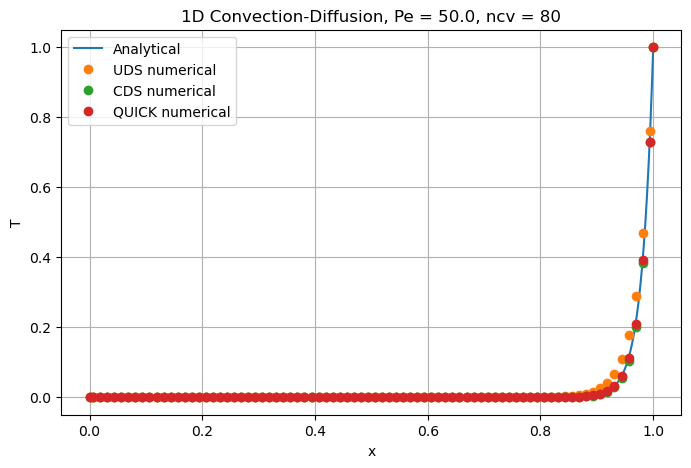

In [7]:
%matplotlib inline
x_exact = np.linspace(0.0, L, 1000)
T_exact = analytical_T(x_exact, L)

for ncv in ncv_list:
    plt.figure(figsize=(8, 5))

    # Analytical solution
    plt.plot(x_exact, T_exact, "-", label="Analytical")

    # Numerical solutions
    for scheme_name in schemes.keys():
        grid = results[ncv][scheme_name]["grid"]
        T_sol = results[ncv][scheme_name]["T"]

        # T_sol includes ghost cells, so use T_sol[1:-1]
        plt.plot(
            grid.xP,
            T_sol,
            "o",
            label=f"{scheme_name} numerical"
        )

    plt.xlabel("x")
    plt.ylabel("T")
    plt.title(f"1D Convection-Diffusion, Pe = {Pe}, ncv = {ncv}")
    plt.legend()
    plt.grid(True)
    plt.show()

## Discussion for different meshes

Mesh is refined from ncv=20 to ncv=80, the numerical solutions become closer to the analytical solution. For ncv=20, the cell Peclet number is Pe
=2.5, so the problem is convection dominated at the cell level. UDS remains stable but is overly diffusive, while CDS can produce unphysical oscillations because Pe > 2. QUICK gives a less diffusive solution than UDS. For ncv=40, Pe=1.25, so CDS becomes stable and both CDS and QUICK agree better with the analytical solution. For ncv=80, Pe=0.625, and the boundary is better resolved. All schemes approach the analytical solution, but UDS remains the most diffusive. Overall, mesh refinement reduces the numerical error, and the higher-order schemes provide better accuracy than UDS on sufficiently fine grids.

## Problem 2

Consider the problem of water flowing through a heated square duct (see the figure below).

![Problem1](Figures/3-Problem2.png)

The properties of water are $\rho$ = 1000 [kg/m$^3$], $k$ = 0.590 [W/m$\cdot$K], and $c_p$ = 4189 [J/kg$\cdot$K]. The exact solution for this problem is:

$$
    \frac{T_{\infty}-T(x)}{T_{\infty}-T_{in}}= e^{-\frac{h P_o x}{\dot{m} c_p}}
$$

To solve this problem, start with 5 equal-length control volumes, initialize the temperature and velocity fields as $T$ = 0 [$^\circ$C] and $u$ = 1.5 [m/s], and use a time-step size of $10^{10}$ [s].  At the left boundary, set $\alpha_e = 1$ to ensure that the correct value of $T$ gets carried into the domain.  Then, carry out the following:

1. Solve the problem using UDS, CDS and QUICK and plot $T$ for all schemes along with $T_{exact}$ vs. $x$ with $\alpha_e$ = -1.0 at the right boundary.  Discuss the results.
2. Test the effect of $\alpha_e$ at the right boundary.  That is, set $\alpha_e$ = 1.0 at the right boundary, run the cases of (1) again and discuss the differences that occur.  What physical effect does setting $\alpha_e = \pm1.0$ at the right boundary have?  Which is realistic?
3. Reverse the flow direction and the boundary conditions re-run parts (1) and (2).  Show plots of $T$ vs. $x$.  Make sure you use appropriate values for $\alpha_e$ on the boundaries.  Your solutions should be the same as those from parts (1) and (2), except opposite.

Based on your results for this problem, make a general statement about how $\alpha_e$ should be set on the boundaries and why.

In [19]:
class UpwindAdvectionModel_q2:
    """Class defining an upwind advection model with user-input boundary alphae"""

    def __init__(
        self, grid, phi, Uhe, rho, cp, west_bc, east_bc,
        alphae_left=None,
        alphae_right=None
    ):
        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc

        self._alphae_left = alphae_left
        self._alphae_right = alphae_right

        self._alphae = np.zeros(self._grid.ncv + 1)
        self._phie = np.zeros(self._grid.ncv + 1)

    def add(self, coeffs):
        """Add UDS advection terms to coefficient arrays"""

        # Default alphae from flow direction
        for i in range(self._grid.ncv + 1):
            if self._Uhe[i] >= 0.0:
                self._alphae[i] = 1.0
            else:
                self._alphae[i] = -1.0

        # User-input boundary alphae
        if self._alphae_left is not None:
            self._alphae[0] = self._alphae_left

        if self._alphae_right is not None:
            self._alphae[-1] = self._alphae_right

        # Face values
        self._phie = (
            (1.0 + self._alphae) / 2.0 * self._phi[0:-1]
            + (1.0 - self._alphae) / 2.0 * self._phi[1:]
        )

        # Face mass fluxes
        mdote = self._rho * self._Uhe * self._grid.Af

        # Face advection fluxes
        flux_w = self._cp * mdote[:-1] * self._phie[:-1]
        flux_e = self._cp * mdote[1:]  * self._phie[1:]

        flux = flux_e - flux_w

        # Mass imbalance term
        imbalance = (
            - self._cp * mdote[1:]  * self._phi[1:-1]
            + self._cp * mdote[:-1] * self._phi[1:-1]
        )

        # Linearization coefficients
        coeffW = - self._cp * mdote[:-1] * (1.0 + self._alphae[:-1]) / 2.0
        coeffE =   self._cp * mdote[1:]  * (1.0 - self._alphae[1:])  / 2.0
        coeffP = - coeffW - coeffE

        # Boundary coefficient treatment
        coeffP[0] += coeffW[0] * self._west_bc.coeff()
        coeffP[-1] += coeffE[-1] * self._east_bc.coeff()

        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux)
        coeffs.accumulate_rP(imbalance)

        return coeffs


class CDSAdvectionModel_q2:
    """Class defining a deferred-correction CDS advection model with user-input boundary alphae"""

    def __init__(
        self, grid, phi, Uhe, rho, cp, west_bc, east_bc,
        alphae_left=None,
        alphae_right=None
    ):
        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc

        self._alphae_left = alphae_left
        self._alphae_right = alphae_right

        self._alphae = np.zeros(self._grid.ncv + 1)
        self._phie_uds = np.zeros(self._grid.ncv + 1)
        self._phie_cds = np.zeros(self._grid.ncv + 1)

    def add(self, coeffs):
        """Add deferred-correction CDS advection terms to coefficient arrays"""

        # Default alphae from flow direction
        for i in range(self._grid.ncv + 1):
            if self._Uhe[i] >= 0.0:
                self._alphae[i] = 1.0
            else:
                self._alphae[i] = -1.0

        # User-input boundary alphae
        if self._alphae_left is not None:
            self._alphae[0] = self._alphae_left

        if self._alphae_right is not None:
            self._alphae[-1] = self._alphae_right

        # UDS face values
        self._phie_uds = (
            (1.0 + self._alphae) / 2.0 * self._phi[0:-1]
            + (1.0 - self._alphae) / 2.0 * self._phi[1:]
        )

        # CDS face values
        self._phie_cds = 0.5 * (self._phi[0:-1] + self._phi[1:])

        # Face mass fluxes
        mdote = self._rho * self._Uhe * self._grid.Af

        # UDS fluxes
        flux_w_uds = self._cp * mdote[:-1] * self._phie_uds[:-1]
        flux_e_uds = self._cp * mdote[1:]  * self._phie_uds[1:]
        flux_uds = flux_e_uds - flux_w_uds

        # CDS fluxes
        flux_w_cds = self._cp * mdote[:-1] * self._phie_cds[:-1]
        flux_e_cds = self._cp * mdote[1:]  * self._phie_cds[1:]
        flux_cds = flux_e_cds - flux_w_cds

        # Deferred correction
        flux = flux_uds + (flux_cds - flux_uds)

        # Mass imbalance term
        imbalance = (
            - self._cp * mdote[1:]  * self._phi[1:-1]
            + self._cp * mdote[:-1] * self._phi[1:-1]
        )

        # Linearization coefficients from UDS
        coeffW = - self._cp * mdote[:-1] * (1.0 + self._alphae[:-1]) / 2.0
        coeffE =   self._cp * mdote[1:]  * (1.0 - self._alphae[1:])  / 2.0
        coeffP = - coeffW - coeffE

        # Boundary coefficient treatment
        coeffP[0] += coeffW[0] * self._west_bc.coeff()
        coeffP[-1] += coeffE[-1] * self._east_bc.coeff()

        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux)
        coeffs.accumulate_rP(imbalance)

        return coeffs


class QUICKAdvectionModel_q2:
    """Class defining a deferred-correction QUICK advection model with user-input boundary alphae"""

    def __init__(
        self, grid, phi, Uhe, rho, cp, west_bc, east_bc,
        alphae_left=None,
        alphae_right=None
    ):
        self._grid = grid
        self._phi = phi
        self._Uhe = Uhe
        self._rho = rho
        self._cp = cp
        self._west_bc = west_bc
        self._east_bc = east_bc

        self._alphae_left = alphae_left
        self._alphae_right = alphae_right

        self._alphae = np.zeros(self._grid.ncv + 1)
        self._phie_uds = np.zeros(self._grid.ncv + 1)
        self._phie_quick = np.zeros(self._grid.ncv + 1)

    def add(self, coeffs):
        """Add deferred-correction QUICK advection terms to coefficient arrays"""

        # Default alphae from flow direction
        for i in range(self._grid.ncv + 1):
            if self._Uhe[i] >= 0.0:
                self._alphae[i] = 1.0
            else:
                self._alphae[i] = -1.0

        # User-input boundary alphae
        if self._alphae_left is not None:
            self._alphae[0] = self._alphae_left

        if self._alphae_right is not None:
            self._alphae[-1] = self._alphae_right

        # UDS face values
        self._phie_uds = (
            (1.0 + self._alphae) / 2.0 * self._phi[0:-1]
            + (1.0 - self._alphae) / 2.0 * self._phi[1:]
        )

        # QUICK face values
        # Boundary faces remain UDS-controlled by alphae.
        self._phie_quick[:] = self._phie_uds[:]

        # QUICK interpolation on interior faces only
        for i in range(1, self._grid.ncv):
            if self._Uhe[i] >= 0.0:
                self._phie_quick[i] = (
                    - self._phi[i - 1]
                    + 6.0 * self._phi[i]
                    + 3.0 * self._phi[i + 1]
                ) / 8.0
            else:
                self._phie_quick[i] = (
                    3.0 * self._phi[i]
                    + 6.0 * self._phi[i + 1]
                    - self._phi[i + 2]
                ) / 8.0

        # Face mass fluxes
        mdote = self._rho * self._Uhe * self._grid.Af

        # UDS fluxes
        flux_w_uds = self._cp * mdote[:-1] * self._phie_uds[:-1]
        flux_e_uds = self._cp * mdote[1:]  * self._phie_uds[1:]
        flux_uds = flux_e_uds - flux_w_uds

        # QUICK fluxes
        flux_w_quick = self._cp * mdote[:-1] * self._phie_quick[:-1]
        flux_e_quick = self._cp * mdote[1:]  * self._phie_quick[1:]
        flux_quick = flux_e_quick - flux_w_quick

        # Deferred correction
        flux = flux_uds + (flux_quick - flux_uds)

        # Mass imbalance term
        imbalance = (
            - self._cp * mdote[1:]  * self._phi[1:-1]
            + self._cp * mdote[:-1] * self._phi[1:-1]
        )

        # Linearization coefficients from UDS
        coeffW = - self._cp * mdote[:-1] * (1.0 + self._alphae[:-1]) / 2.0
        coeffE =   self._cp * mdote[1:]  * (1.0 - self._alphae[1:])  / 2.0
        coeffP = - coeffW - coeffE

        # Boundary coefficient treatment
        coeffP[0] += coeffW[0] * self._west_bc.coeff()
        coeffP[-1] += coeffE[-1] * self._east_bc.coeff()

        coeffW[0] = 0.0
        coeffE[-1] = 0.0

        # Add to coefficient arrays
        coeffs.accumulate_aP(coeffP)
        coeffs.accumulate_aW(coeffW)
        coeffs.accumulate_aE(coeffE)
        coeffs.accumulate_rP(flux)
        coeffs.accumulate_rP(imbalance)

        return coeffs

In [20]:
def analytical_T_surface_convection(x, T_inf, T_in, h, P, mdot, cp):
    return T_inf + (T_in - T_inf) * np.exp(-h * P * x / (mdot * cp))

In [21]:
def run_surface_convection_advection_case(
    ncv,
    advection_class,
    alphae_left=1.0,
    alphae_right=1.0
):
    # Define the grid
    lx = 5.0
    ly = 0.01
    lz = 0.01
    grid = Grid(lx, ly, lz, ncv)

    # Time information
    nTime = 1
    dt = 1e10
    time = 0.0

    # Iteration settings
    maxIter = 100
    converged = 1e-8

    # Thermophysical properties
    rho = 1000.0
    cp = 4189.0
    k = 0.59

    # Surface convection parameters
    ho = 10000.0
    To = 100.0

    # Initial conditions
    T0 = 0.0
    U0 = 1.5

    T = T0 * np.ones(grid.ncv + 2)
    Uhe = U0 * np.ones(grid.ncv + 1)

    # Boundary conditions
    west_bc = DirichletBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.EAST)

    west_bc.apply()
    east_bc.apply()

    # Old field
    Told = np.copy(T)

    # Models
    transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dt)
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)

    # Important: pass alphae_left and alphae_right into the q2 class
    advection = advection_class(
        grid, T, Uhe, rho, cp, west_bc, east_bc,
        alphae_left=alphae_left,
        alphae_right=alphae_right
    )

    # Coefficients
    coeffs = ScalarCoeffs(grid.ncv)

    # Time loop
    for tStep in range(nTime):
        time += dt

        print(f"\nncv = {ncv}, Scheme = {advection_class.__name__}")
        print(f"alphae_left = {alphae_left}, alphae_right = {alphae_right}")
        print(f"Timestep = {tStep}; Time = {time}")

        Told[:] = T[:]

        for i in range(maxIter):
            coeffs.zero()

            coeffs = diffusion.add(coeffs)
            coeffs = surfaceConvection.add(coeffs)
            coeffs = advection.add(coeffs)
            coeffs = transient.add(coeffs)

            maxResid = norm(coeffs.rP, np.inf)
            avgResid = np.mean(np.absolute(coeffs.rP))

            print(
                "Iteration = {}; Max. Resid. = {:.4e}; Avg. Resid. = {:.4e}".format(
                    i, maxResid, avgResid
                )
            )

            if maxResid < converged:
                break

            dT = solve(coeffs)

            T[1:-1] += dT

            west_bc.apply()
            east_bc.apply()

    return grid, np.copy(T)

In [22]:
ncv = 5

alphae_left = 1.0
alphae_right = -1.0

schemes = {
    "UDS": UpwindAdvectionModel_q2,
    "CDS": CDSAdvectionModel_q2,
    "QUICK": QUICKAdvectionModel_q2,
}

results_5 = {}

for scheme_name, scheme_class in schemes.items():
    grid, T_sol = run_surface_convection_advection_case(
        ncv=ncv,
        advection_class=scheme_class,
        alphae_left=alphae_left,
        alphae_right=alphae_right
    )

    results_5[scheme_name] = {
        "grid": grid,
        "T": T_sol,
    }


ncv = 5, Scheme = UpwindAdvectionModel_q2
alphae_left = 1.0, alphae_right = -1.0
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 4.0000e+04; Avg. Resid. = 4.0000e+04
Iteration = 1; Max. Resid. = 2.9494e-11; Avg. Resid. = 9.9599e-12

ncv = 5, Scheme = CDSAdvectionModel_q2
alphae_left = 1.0, alphae_right = -1.0
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 4.0000e+04; Avg. Resid. = 4.0000e+04
Iteration = 1; Max. Resid. = 4.7535e+03; Avg. Resid. = 2.4441e+03
Iteration = 2; Max. Resid. = 1.1298e+03; Avg. Resid. = 4.1300e+02
Iteration = 3; Max. Resid. = 3.3564e+02; Avg. Resid. = 1.4748e+02
Iteration = 4; Max. Resid. = 1.1168e+02; Avg. Resid. = 5.7278e+01
Iteration = 5; Max. Resid. = 5.6236e+01; Avg. Resid. = 3.5224e+01
Iteration = 6; Max. Resid. = 3.5120e+01; Avg. Resid. = 2.3333e+01
Iteration = 7; Max. Resid. = 2.6254e+01; Avg. Resid. = 1.5779e+01
Iteration = 8; Max. Resid. = 1.8591e+01; Avg. Resid. = 1.0556e+01
Iteration = 9; Max. Resid. = 1.3257e+01; Av

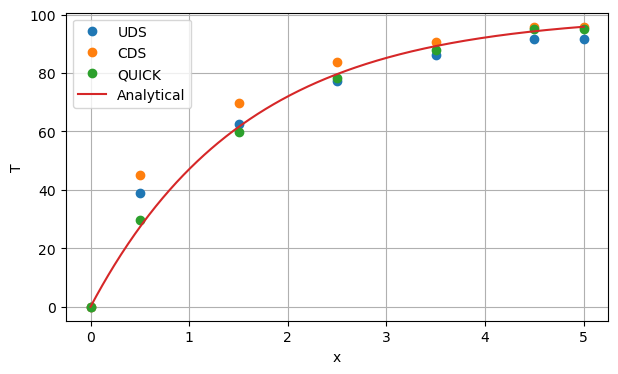

In [28]:
%matplotlib inline
import matplotlib.pyplot as plt

# Define properties
rho = 1000.0
cp = 4189.0
k = 0.59


ho = 10000.0
To = 100.0

A = 0.01 * 0.01
P = 2.0 * (0.01 + 0.01)
mdot = rho * U0 * A
x_an = np.linspace(0.0, 5, 500)
T_an =  analytical_T_surface_convection(x_an, To, 0, ho, P, mdot, cp)

plt.figure(figsize=(7, 4))

# Numerical solutions
for scheme_name in schemes.keys():
    grid = results_5[scheme_name]["grid"]
    T_sol = results_5[scheme_name]["T"]

    plt.plot(
        grid.xP,
        T_sol,
        marker="o",
        linestyle="none",
        label=scheme_name
    )
        
plt.plot(x_an, T_an, "-", label="Analytical")

plt.xlabel("x")
plt.ylabel("T")
plt.legend()
plt.grid(True)
plt.show()

## Q2

## Q3 Reversed flow

In [39]:
def run_surface_convection_advection_case_reversed(
    ncv,
    advection_class,
    alphae_left=1.0,
    alphae_right=1.0
):
    # Define the grid
    lx = 5.0
    ly = 0.01
    lz = 0.01
    grid = Grid(lx, ly, lz, ncv)

    # Time information
    nTime = 1
    dt = 1e10
    time = 0.0

    # Iteration settings
    maxIter = 100
    converged = 1e-8

    # Thermophysical properties
    rho = 1000.0
    cp = 4189.0
    k = 0.59

    # Surface convection parameters
    ho = 10000.0
    To = 100.0

    # Initial conditions
    T0 = 0.0
    U0 = -1.5

    T = T0 * np.ones(grid.ncv + 2)
    Uhe = U0 * np.ones(grid.ncv + 1)

    # Boundary conditions
    west_bc = NeumannBc(T, grid, 0.0, BoundaryLocation.WEST)
    east_bc = DirichletBc(T, grid, 0.0, BoundaryLocation.EAST)

    west_bc.apply()
    east_bc.apply()

    # Old field
    Told = np.copy(T)

    # Models
    transient = FirstOrderTransientModel(grid, T, Told, rho, cp, dt)
    diffusion = DiffusionModel(grid, T, k, west_bc, east_bc)
    surfaceConvection = SurfaceConvectionModel(grid, T, ho, To)

    # Important: pass alphae_left and alphae_right into the q2 class
    advection = advection_class(
        grid, T, Uhe, rho, cp, west_bc, east_bc,
        alphae_left=alphae_left,
        alphae_right=alphae_right
    )

    # Coefficients
    coeffs = ScalarCoeffs(grid.ncv)

    # Time loop
    for tStep in range(nTime):
        time += dt

        print(f"\nncv = {ncv}, Scheme = {advection_class.__name__}")
        print(f"alphae_left = {alphae_left}, alphae_right = {alphae_right}")
        print(f"Timestep = {tStep}; Time = {time}")

        Told[:] = T[:]

        for i in range(maxIter):
            coeffs.zero()

            coeffs = diffusion.add(coeffs)
            coeffs = surfaceConvection.add(coeffs)
            coeffs = advection.add(coeffs)
            coeffs = transient.add(coeffs)

            maxResid = norm(coeffs.rP, np.inf)
            avgResid = np.mean(np.absolute(coeffs.rP))

            print(
                "Iteration = {}; Max. Resid. = {:.4e}; Avg. Resid. = {:.4e}".format(
                    i, maxResid, avgResid
                )
            )

            if maxResid < converged:
                break

            dT = solve(coeffs)

            T[1:-1] += dT

            west_bc.apply()
            east_bc.apply()

    return grid, np.copy(T)

In [40]:
ncv = 5

alphae_left = -1.0
alphae_right = 1.0

schemes = {
    "UDS": UpwindAdvectionModel_q2,
    "CDS": CDSAdvectionModel_q2,
    "QUICK": QUICKAdvectionModel_q2,
}

results_5_reversed = {}

for scheme_name, scheme_class in schemes.items():
    grid, T_sol = run_surface_convection_advection_case_reversed(
        ncv=ncv,
        advection_class=scheme_class,
        alphae_left=-1.0,
        alphae_right=-1.0
    )

    results_5_reversed[scheme_name] = {
        "grid": grid,
        "T": T_sol,
    }


ncv = 5, Scheme = UpwindAdvectionModel_q2
alphae_left = -1.0, alphae_right = -1.0
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 4.0000e+04; Avg. Resid. = 4.0000e+04
Iteration = 1; Max. Resid. = 1.6761e-11; Avg. Resid. = 4.0318e-12

ncv = 5, Scheme = CDSAdvectionModel_q2
alphae_left = -1.0, alphae_right = -1.0
Timestep = 0; Time = 10000000000.0
Iteration = 0; Max. Resid. = 4.0000e+04; Avg. Resid. = 4.0000e+04
Iteration = 1; Max. Resid. = 4.7535e+03; Avg. Resid. = 2.4441e+03
Iteration = 2; Max. Resid. = 1.1298e+03; Avg. Resid. = 4.1300e+02
Iteration = 3; Max. Resid. = 3.3564e+02; Avg. Resid. = 1.4748e+02
Iteration = 4; Max. Resid. = 1.1168e+02; Avg. Resid. = 5.7278e+01
Iteration = 5; Max. Resid. = 5.6236e+01; Avg. Resid. = 3.5224e+01
Iteration = 6; Max. Resid. = 3.5120e+01; Avg. Resid. = 2.3333e+01
Iteration = 7; Max. Resid. = 2.6254e+01; Avg. Resid. = 1.5779e+01
Iteration = 8; Max. Resid. = 1.8591e+01; Avg. Resid. = 1.0556e+01
Iteration = 9; Max. Resid. = 1.3257e+01; 

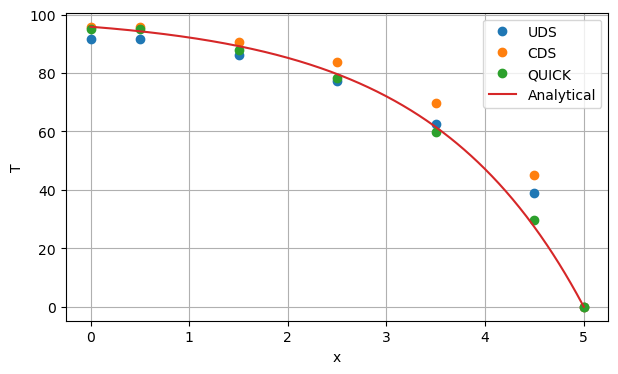

In [41]:
%matplotlib inline
import matplotlib.pyplot as plt

# Define properties
rho = 1000.0
cp = 4189.0
k = 0.59


ho = 10000.0
To = 100.0

A = 0.01 * 0.01
P = 2.0 * (0.01 + 0.01)
mdot = rho * U0 * A
x_an = np.linspace(0.0, 5, 500)
T_an =  analytical_T_surface_convection(5 - x_an, To, 0, ho, P, mdot, cp)

plt.figure(figsize=(7, 4))

# Numerical solutions
for scheme_name in schemes.keys():
    grid = results_5_reversed[scheme_name]["grid"]
    T_sol = results_5_reversed[scheme_name]["T"]

    plt.plot(
        grid.xP,
        T_sol,        # remove ghost cells
        marker="o",
        linestyle="None",   # no line between numerical points
        label=scheme_name
    )
        
plt.plot(x_an, T_an, "-", label="Analytical")

plt.xlabel("x")
plt.ylabel("T")
plt.legend()
plt.grid(True)
plt.show()